<a href="https://colab.research.google.com/github/ashwini-ah18/Artificial-Intelligence/blob/main/Multiclass_classification_project_with_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Multiclass classification project with Keras

Build a model that can predict the price of the mobile on the basis of the mobile's specifications

In [1]:

import pandas as pd
path = r"https://raw.githubusercontent.com/sindhura-nk/Datasets/refs/heads/main/mobile_train%20(1).csv"
df = pd.read_csv(path)
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [2]:

df['price_range'].value_counts()

,count
price_range,
1,500
2,500
3,500
0,500


## Perform the basic quality checks


In [3]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [4]:

df.duplicated().sum()

np.int64(0)

In [5]:

df.isna().sum()

,0
battery_power,0
blue,0
clock_speed,0
dual_sim,0
fc,0
four_g,0
int_memory,0
m_dep,0
mobile_wt,0
n_cores,0


## Separate the data into X and Y features
Y = price_range

In [6]:

X = df.drop(columns='price_range')
Y = df[['price_range']]

In [7]:

X.head()


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0


In [8]:
Y.head()

,price_range
0,1
1,2
2,2
3,2
4,1


## SPlit the data into training and testing

In [9]:

len(X)


2000

In [10]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(X,Y,train_size=0.85,random_state=21)


In [11]:
xtrain.shape


(1700, 20)

In [12]:

xtest.shape

(300, 20)

## Data cleaning and preprocessing

In [13]:
xtrain.dtypes

,0
battery_power,int64
blue,int64
clock_speed,float64
dual_sim,int64
fc,int64
four_g,int64
int_memory,int64
m_dep,float64
mobile_wt,int64
n_cores,int64


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

num_pipe = make_pipeline(SimpleImputer(strategy='median'),
                         StandardScaler()).set_output(transform='pandas')

num_pipe

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler())])

In [15]:

num_pipe.fit(xtrain)

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler())])

In [16]:

xtrain_pre = num_pipe.transform(xtrain)
xtest_pre = num_pipe.transform(xtest)

In [17]:
xtrain_pre.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
1465,-1.690716,-0.982506,1.319432,-1.019004,-0.992580,-1.035940,0.050334,-1.373349,-0.852035,0.626635,-0.005045,0.909385,1.515538,-0.402935,-1.510575,-0.858492,-1.118686,-1.796902,0.987141,-1.011835
1095,-1.084650,1.017806,1.197103,0.981350,-0.765659,0.965307,-1.219382,-1.373349,1.273509,1.063046,0.654681,-0.461598,0.713626,-0.378819,1.584234,-0.630170,1.273935,0.556513,0.987141,0.988304
995,0.472826,-0.982506,0.096137,0.981350,0.142026,-1.035940,0.933615,-1.027929,1.500234,-0.682598,1.644271,1.434777,0.413495,1.388200,-0.082201,1.196409,0.905840,0.556513,0.987141,-1.011835
335,-1.020613,-0.982506,-0.882500,0.981350,-0.992580,-1.035940,-0.777742,-0.682509,-0.965397,-0.246187,-1.489429,-0.048950,-0.740133,0.624811,1.346172,2.109699,0.169649,-1.796902,0.987141,-1.011835
1804,1.035438,1.017806,0.952443,0.981350,1.730474,0.965307,0.823204,0.353751,-0.937056,-1.119009,1.479339,1.432523,0.919966,-1.421406,-0.558326,-1.315137,1.457983,0.556513,-1.013026,0.988304


In [18]:

ytrain['price_range'].value_counts()

,count
price_range,
2,438
1,426
3,424
0,412


## Encoding of Y target varible - multiclass classification

In [21]:

from keras.utils import to_categorical
ytrain_pre = to_categorical(ytrain)
ytest_pre = to_categorical(ytest)


In [22]:

ytrain_pre[:10]

array([[0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.]])

In [24]:

ytrain_pre.shape

(1700, 4)

In [25]:

ytrain_pre.shape[1]

4

## Model Building

In [26]:

xtrain.shape

(1700, 20)

In [27]:
from keras.models import Sequential
from keras.layers import Input,Dense,Dropout
from keras.callbacks import EarlyStopping

# Intialize the model
model = Sequential()

# Add the Input layer
model.add(Input(shape=(xtrain.shape[1],)))

# Add the Hidden layer1
model.add(Dense(units=64,activation="relu"))
model.add(Dropout(rate=0.4))

# Add the Hidden layer1
model.add(Dense(units=32,activation="relu"))
model.add(Dropout(rate=0.2))

# Add the Output layer
model.add(Dense(units=ytrain_pre.shape[1],activation='softmax'))

# Look at the summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,556 (13.89 KB)

 Trainable params: 3,556 (13.89 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# Backpropagation
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [29]:

es = EarlyStopping(monitor='val_loss',patience=10)

In [30]:


nn = model.fit(xtrain_pre,ytrain_pre,validation_split=0.15,epochs=200,callbacks=[es])

Epoch 1/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.3253 - loss: 1.4326 - val_accuracy: 0.5020 - val_loss: 1.2277
Epoch 2/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4138 - loss: 1.2448 - val_accuracy: 0.5882 - val_loss: 1.0819
Epoch 3/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4962 - loss: 1.1017 - val_accuracy: 0.6784 - val_loss: 0.9199
Epoch 4/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5668 - loss: 0.9608 - val_accuracy: 0.7137 - val_loss: 0.7863
Epoch 5/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6138 - loss: 0.8587 - val_accuracy: 0.7529 - val_loss: 0.6804
Epoch 6/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6727 - loss: 0.7362 - val_accuracy: 0.7961 - val_loss: 0.5997
Epoch 7/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6810 - loss: 0.6929 - val_accuracy: 0.8431 - val_loss: 0.5355
Epoch 8/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7107 - loss: 0.6477 - val_accuracy: 0.8706 

## Learning Curve

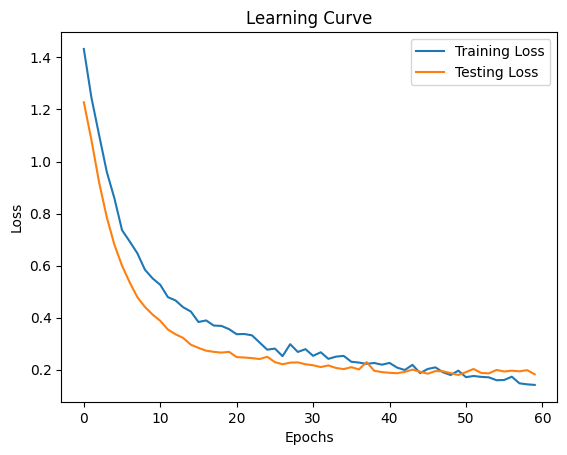

In [31]:
import matplotlib.pyplot as plt

plt.plot(nn.history['loss'],label="Training Loss")
plt.plot(nn.history['val_loss'],label="Testing Loss")
plt.title("Learning Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


## Model evaluation

In [32]:

model.evaluate(xtrain_pre,ytrain_pre)

54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9871 - loss: 0.0636


[0.06358860433101654, 0.9870588183403015]

In [33]:

model.evaluate(xtest_pre,ytest_pre)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.9367 - loss: 0.1802


[0.18020425736904144, 0.9366666674613953]

## Confusion matrix and classification report


In [34]:
from sklearn.metrics import classification_report,ConfusionMatrixDisplay
import numpy as np

ypreds = model.predict(xtest_pre)
ypreds = [np.argmax(i) for i in ypreds]
ypreds[:10]

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step


[np.int64(3),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(3),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(3),
 np.int64(0)]

In [35]:

ytrain.head(1)

,price_range
1465,1


In [36]:

ytrain_pre[:1]

array([[0., 1., 0., 0.]])

In [37]:
import numpy as np

In [38]:
a1 = [[0.9,0.08,0.45,0.33],
      [0.09,0.34,0.56,0.89]]
a1

[[0.9, 0.08, 0.45, 0.33], [0.09, 0.34, 0.56, 0.89]]

In [39]:
print(np.argmax(a1[0]))
print(np.argmax(a1[1]))


0
3


In [40]:
print(classification_report(ytest,ypreds))


              precision    recall  f1-score   support

           0       0.94      0.95      0.95        88
           1       0.93      0.92      0.93        74
           2       0.92      0.92      0.92        62
           3       0.95      0.95      0.95        76

    accuracy                           0.94       300
   macro avg       0.94      0.94      0.94       300
weighted avg       0.94      0.94      0.94       300



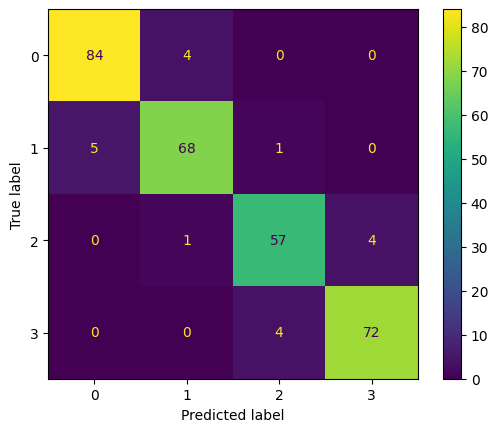

In [41]:
ConfusionMatrixDisplay.from_predictions(ytest,ypreds)

## This model can be finalised for model deployment

In [42]:

model.save("MobilePricePrediction.keras")
import joblib
joblib.dump(num_pipe,"pipeline.joblib")

['pipeline.joblib']

# Out of sample predictions - this part of work is to give you a practice of always pulling NEW input data, transforming that data using pipeline and making the PREDICTIONS

In [43]:
from keras.models import load_model
model_loaded = load_model(r"/content/MobilePricePrediction.keras")

pipe = joblib.load(r"/content/pipeline.joblib")

In [44]:
model_loaded.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,670 (41.68 KB)

 Trainable params: 3,556 (13.89 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,114 (27.79 KB)

In [45]:

pipe

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler())])

In [46]:

df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [47]:
path2 = r"https://raw.githubusercontent.com/sindhura-nk/Datasets/refs/heads/main/mobile_test%20(1).csv"
xnew = pd.read_csv(path2)
xnew.head()

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1,1043,1,1.8,1,14,0,5,0.1,193,...,16,226,1412,3476,12,7,2,0,1,0
1,2,841,1,0.5,1,4,1,61,0.8,191,...,12,746,857,3895,6,0,7,1,0,0
2,3,1807,1,2.8,0,1,0,27,0.9,186,...,4,1270,1366,2396,17,10,10,0,1,1
3,4,1546,0,0.5,1,18,1,25,0.5,96,...,20,295,1752,3893,10,0,7,1,1,0
4,5,1434,0,1.4,0,11,1,49,0.5,108,...,18,749,810,1773,15,8,7,1,0,1


In [48]:
xnew_copy = xnew.drop(columns='id')
xnew_copy.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1043,1,1.8,1,14,0,5,0.1,193,3,16,226,1412,3476,12,7,2,0,1,0
1,841,1,0.5,1,4,1,61,0.8,191,5,12,746,857,3895,6,0,7,1,0,0
2,1807,1,2.8,0,1,0,27,0.9,186,3,4,1270,1366,2396,17,10,10,0,1,1
3,1546,0,0.5,1,18,1,25,0.5,96,8,20,295,1752,3893,10,0,7,1,1,0
4,1434,0,1.4,0,11,1,49,0.5,108,6,18,749,810,1773,15,8,7,1,0,1


In [49]:
xnew_copy_pre = pipe.transform(xnew_copy)

# predictions
preds = model_loaded.predict(xnew_copy_pre)
preds = [np.argmax(i) for i in preds]
preds[:10]


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


[np.int64(3),
 np.int64(3),
 np.int64(3),
 np.int64(3),
 np.int64(1),
 np.int64(3),
 np.int64(3),
 np.int64(1),
 np.int64(3),
 np.int64(0)]

In [50]:
xnew.head(3)

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1,1043,1,1.8,1,14,0,5,0.1,193,...,16,226,1412,3476,12,7,2,0,1,0
1,2,841,1,0.5,1,4,1,61,0.8,191,...,12,746,857,3895,6,0,7,1,0,0
2,3,1807,1,2.8,0,1,0,27,0.9,186,...,4,1270,1366,2396,17,10,10,0,1,1


In [51]:
xnew["Price Range PRedicted"] = preds
xnew.head(2)

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,Price Range PRedicted
0,1,1043,1,1.8,1,14,0,5,0.1,193,...,226,1412,3476,12,7,2,0,1,0,3
1,2,841,1,0.5,1,4,1,61,0.8,191,...,746,857,3895,6,0,7,1,0,0,3


In [52]:
xnew.to_csv("Price Range predicted.csv",index=False)
